正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
正在计算核心财务指标 (ROE与盈利含金量)...
开始执行【巴菲特高ROE现金流白马】半年度调仓模拟...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\quant\回测excel\巴菲特价值长线策略明细.xlsx
正在计算画图所需的连贯资产曲线...

💰 初始本金: 50,000.00 元
💰 最终总资产: 18,046.31 元
📈 策略总收益率: -63.91%


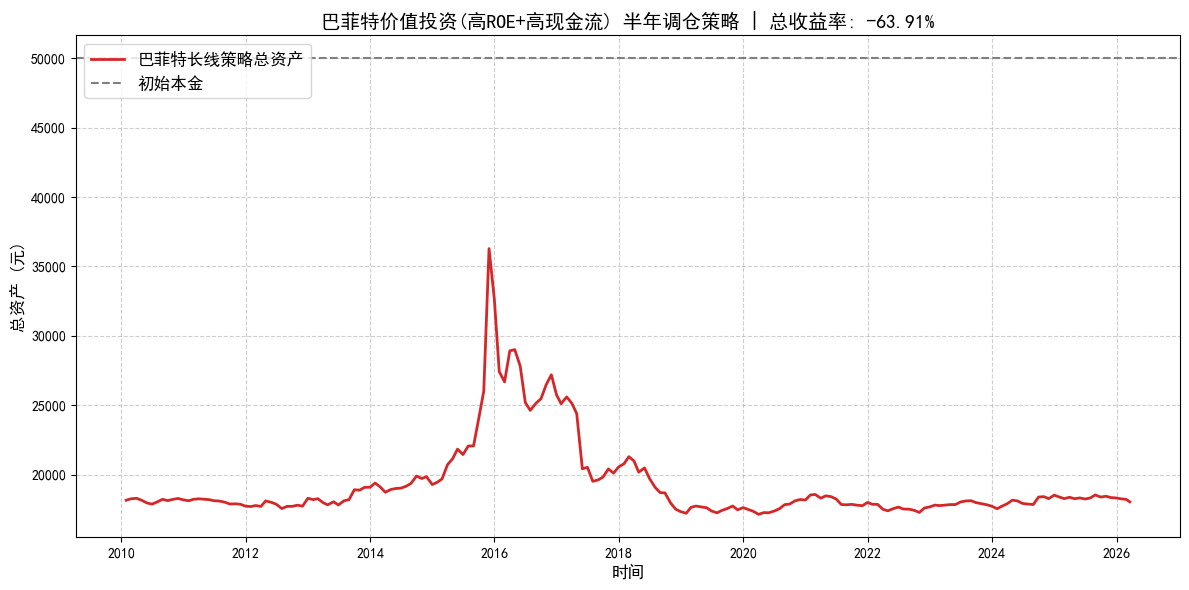

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\巴菲特价值长线策略明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：构建巴菲特核心财务指标
# ==========================================
print("正在计算核心财务指标 (ROE与盈利含金量)...")
# 1. 计算净资产
df['net_asset'] = df['资产总计'] - df['负债合计']

# 2. 计算 ROE (剔除资不抵债的公司)
df['ROE'] = np.where(df['net_asset'] > 0, df['净利润'] / df['net_asset'], np.nan)

# 3. 计算盈利含金量 (经营现金流 / 净利润)
df['earnings_quality'] = np.where(df['净利润'] > 0, df['经营活动产生的现金流量净额'] / df['净利润'], np.nan)

df.sort_values(by=['date', 'code'], inplace=True)

# ==========================================
# 第三步：生成【半年度】调仓日
# ==========================================
# 我们只在每年的 5月末 和 10月末 调仓
df['year_month'] = df['date'].dt.to_period('M')
all_month_ends = df.groupby('year_month')['date'].max()

trade_dates = all_month_ends[all_month_ends.dt.month.isin([5, 10])].sort_values().tolist()

# ==========================================
# 第四步：定义交易费率与账户类
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# 第五步：执行巴菲特价值轮动引擎
# ==========================================
print("开始执行【巴菲特高ROE现金流白马】半年度调仓模拟...")

# 将数据按日期分组，加快查询速度
grouped_by_date = dict(tuple(df.groupby('date')))

for date in trade_dates:
    if date not in grouped_by_date: continue

    daily_data = grouped_by_date[date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 巴菲特严苛选股逻辑 ----------------
    # 基础条件：正常交易、非ST
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                            (daily_data['isST'] == 0)].copy()

    target_codes = []
    if len(valid_pool) > 100:
        # 1. 规模过滤：只看全市场流通市值前 50% 的中大盘股
        median_mv = valid_pool['流通市值'].median()
        pool = valid_pool[valid_pool['流通市值'] >= median_mv].copy()

        # 2. 护城河过滤：PE在0-30之间，ROE > 15%，盈利含金量 > 0.8
        buffett_pool = pool[
            (pool['peTTM'] > 0) & (pool['peTTM'] < 30) &
            (pool['ROE'] > 0.15) &
            (pool['earnings_quality'] > 0.8)
        ].copy()

        # 3. 最终优选：在满足所有严苛条件的好公司里，按照 ROE 从高到低排序，买最赚钱的 10 只
        if len(buffett_pool) > 0:
            target_codes = buffett_pool.sort_values(by='ROE', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        # 退市检测
        if code not in daily_data.index:
            lost_vol = account.positions[code]['volume']
            last_price = account.positions[code]['price']
            loss_amount = lost_vol * last_price
            del account.positions[code]
            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol, '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': f'退市亏损 {round(loss_amount, 2)}元'
            })
            continue

        # 如果基本面恶化，跌出巴菲特选股池，则卖出
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol, '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '基本面下滑，换仓卖出'
                })
            elif not is_trading:
                pass # 停牌静默持有

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]
    current_pos_count = len(account.positions)
    free_slots = max(0, TARGET_STOCK_NUM - current_pos_count)
    actual_stocks_to_buy = stocks_to_buy[:free_slots]

    if len(actual_stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(actual_stocks_to_buy)

        for code in actual_stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.3:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        # 记录买入时的基本面数据，方便复盘
                        roe_val = daily_data.loc[code, 'ROE']
                        pe_val = daily_data.loc[code, 'peTTM']

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol, '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': f'买入优秀白马 | ROE:{roe_val:.1%}, PE:{pe_val:.1f}'
                        })

# ==========================================
# 第六步：输出结果与可视化
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

# 补充非调仓日的净资产画图 (为了曲线更连贯，计算每月末的总资产)
print("正在计算画图所需的连贯资产曲线...")
all_month_ends = df.groupby('year_month')['date'].max().sort_values().tolist()
monthly_assets = []
for m_date in all_month_ends:
    if m_date in grouped_by_date:
        d_data = grouped_by_date[m_date].set_index('code')
        c_prices = d_data['close'].to_dict()
        monthly_assets.append({'date': m_date, 'total_asset': account.get_total_asset(m_date, c_prices)})

df_assets = pd.DataFrame(monthly_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"\n💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#d62728', linewidth=2, label='巴菲特长线策略总资产')
plt.title(f'巴菲特价值投资(高ROE+高现金流) 半年调仓策略 | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()